In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [11]:
df = pd.read_csv("/Users/furkandurmaz/Library/Mobile Documents/com~apple~CloudDocs/KocUniversity/Projects/MarketinABTest/marketing_AB.csv")
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [12]:

# Temiz veri
df_clean = df[df['total ads'] <= 500].copy()


### Feature Engineering using XGBoost

In [14]:
# Feature engineering
df_model = df_clean.copy()

# most ads day → sayısal
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_model['day_num'] = df_model['most ads day'].map({d:i for i,d in enumerate(day_order)})

# test group → binary
df_model['is_ad'] = (df_model['test group'] == 'ad').astype(int)

# Feature ve target
features = ['total ads', 'most ads hour', 'day_num', 'is_ad']
X = df_model[features]
y = df_model['converted'].astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Conversion rate train: {y_train.mean():.4f}")

Train: 470012, Test: 117504
Conversion rate train: 0.0251


In [15]:
# Class imbalance için scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)

# Değerlendir
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")
print(classification_report(y_test, model.predict(X_test)))

AUC-ROC: 0.8566
              precision    recall  f1-score   support

           0       0.99      0.80      0.89    114556
           1       0.09      0.78      0.17      2948

    accuracy                           0.80    117504
   macro avg       0.54      0.79      0.53    117504
weighted avg       0.97      0.80      0.87    117504



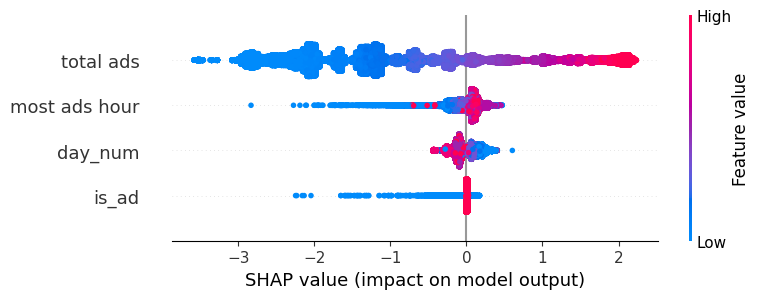

In [16]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)

### Uplift Model

In [17]:
from xgboost import XGBClassifier

# Grupları ayır
train_ad = X_train[X_train['is_ad'] == 1].drop('is_ad', axis=1)
train_psa = X_train[X_train['is_ad'] == 0].drop('is_ad', axis=1)
y_train_ad = y_train[X_train['is_ad'] == 1]
y_train_psa = y_train[X_train['is_ad'] == 0]

# İki ayrı model
model_ad = XGBClassifier(n_estimators=100, max_depth=4, 
                          learning_rate=0.1, scale_pos_weight=scale,
                          random_state=42)
model_psa = XGBClassifier(n_estimators=100, max_depth=4,
                           learning_rate=0.1, scale_pos_weight=scale,
                           random_state=42)

model_ad.fit(train_ad, y_train_ad)
model_psa.fit(train_psa, y_train_psa)

# Test seti üzerinde uplift hesapla
X_test_no_ad = X_test.drop('is_ad', axis=1)

uplift = (model_ad.predict_proba(X_test_no_ad)[:, 1] - 
          model_psa.predict_proba(X_test_no_ad)[:, 1])

print(f"Ortalama uplift: {uplift.mean():.4f}")
print(f"Pozitif uplift (Persuadable): {(uplift > 0).sum()}")
print(f"Negatif uplift (Sleeping Dog): {(uplift < 0).sum()}")

Ortalama uplift: 0.0489
Pozitif uplift (Persuadable): 75837
Negatif uplift (Sleeping Dog): 41667


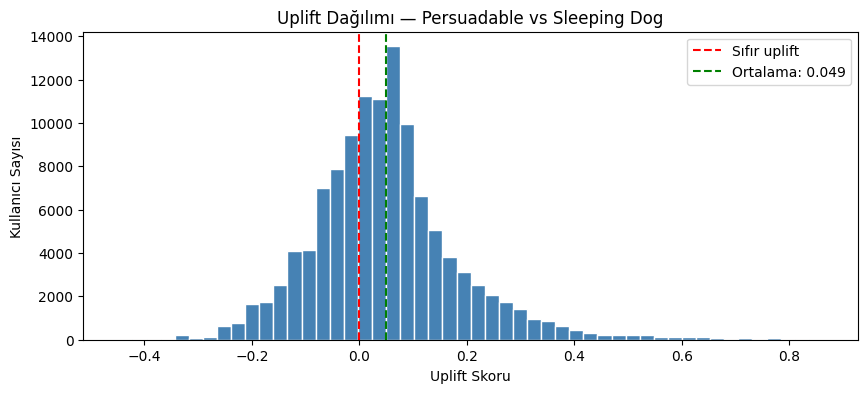

day_num_grp
Az (<20)         0.004868
Orta (20-100)    0.133894
Çok (>100)       0.137633
Name: uplift, dtype: float32


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Uplift dağılımı
plt.figure(figsize=(10, 4))
plt.hist(uplift, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='Sıfır uplift')
plt.axvline(uplift.mean(), color='green', linestyle='--', label=f'Ortalama: {uplift.mean():.3f}')
plt.xlabel('Uplift Skoru')
plt.ylabel('Kullanıcı Sayısı')
plt.title('Uplift Dağılımı — Persuadable vs Sleeping Dog')
plt.legend()
plt.show()

# Segment bazında ortalama uplift
df_test = X_test.copy()
df_test['uplift'] = uplift
df_test['day_num_grp'] = pd.cut(df_test['total ads'], 
                                 bins=[0,20,100,500], 
                                 labels=['Az (<20)', 'Orta (20-100)', 'Çok (>100)'])

segment_uplift = df_test.groupby('day_num_grp', observed=True)['uplift'].mean()
print(segment_uplift)

In [23]:
import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale,
        'random_state': 42,
        'eval_metric': 'auc'
    }
    
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, 
                             cv=3, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"En iyi AUC: {study.best_value:.4f}")
print(f"En iyi parametreler: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]

En iyi AUC: 0.8592
En iyi parametreler: {'n_estimators': 242, 'max_depth': 3, 'learning_rate': 0.041577838908422746, 'subsample': 0.8502415814843847, 'colsample_bytree': 0.7310531496281829}


In [24]:
best_model = XGBClassifier(
    **study.best_params,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc'
)

best_model.fit(X_train, y_train)

y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]
auc_best = roc_auc_score(y_test, y_pred_proba_best)
print(f"Final AUC: {auc_best:.4f}")
print(classification_report(y_test, best_model.predict(X_test)))

Final AUC: 0.8568
              precision    recall  f1-score   support

           0       0.99      0.80      0.88    114556
           1       0.09      0.79      0.16      2948

    accuracy                           0.80    117504
   macro avg       0.54      0.79      0.52    117504
weighted avg       0.97      0.80      0.87    117504



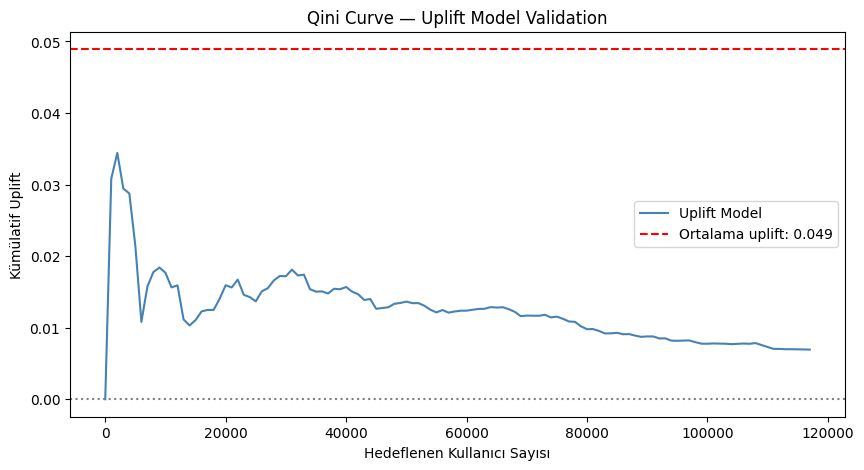

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Test setinde gerçek grup ve conversion bilgisi
df_uplift_eval = X_test.copy()
df_uplift_eval['uplift_score'] = uplift
df_uplift_eval['converted'] = y_test.values
df_uplift_eval['is_ad'] = X_test['is_ad'].values

# Uplift skoruna göre sırala (yüksekten düşüğe)
df_uplift_eval = df_uplift_eval.sort_values('uplift_score', ascending=False).reset_index(drop=True)

# Kümülatif uplift hesapla
n = len(df_uplift_eval)
cumulative_uplift = []

for i in range(1, n+1, 1000):  # Her 1000 kişide bir hesapla
    subset = df_uplift_eval.iloc[:i]
    
    ad_conv = subset[subset['is_ad']==1]['converted'].mean()
    psa_conv = subset[subset['is_ad']==0]['converted'].mean()
    
    if not np.isnan(ad_conv) and not np.isnan(psa_conv):
        cumulative_uplift.append(ad_conv - psa_conv)
    else:
        cumulative_uplift.append(0)

x_axis = range(1, n+1, 1000)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, cumulative_uplift, label='Uplift Model', color='steelblue')
plt.axhline(y=uplift.mean(), color='red', linestyle='--', label=f'Ortalama uplift: {uplift.mean():.3f}')
plt.axhline(y=0, color='gray', linestyle=':')
plt.xlabel('Hedeflenen Kullanıcı Sayısı')
plt.ylabel('Kümülatif Uplift')
plt.title('Qini Curve — Uplift Model Validation')
plt.legend()
plt.show()